In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv(r"C:\Users\lenovo\OneDrive\Desktop\Folder\daily-python-data-lab\04_machine_learning\On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2026_1.csv", low_memory=False)

In [5]:
df.columns.to_list()

['Year',
 'Quarter',
 'Month',
 'DayofMonth',
 'DayOfWeek',
 'FlightDate',
 'Reporting_Airline',
 'DOT_ID_Reporting_Airline',
 'IATA_CODE_Reporting_Airline',
 'Tail_Number',
 'Flight_Number_Reporting_Airline',
 'OriginAirportID',
 'OriginAirportSeqID',
 'OriginCityMarketID',
 'Origin',
 'OriginCityName',
 'OriginState',
 'OriginStateFips',
 'OriginStateName',
 'OriginWac',
 'DestAirportID',
 'DestAirportSeqID',
 'DestCityMarketID',
 'Dest',
 'DestCityName',
 'DestState',
 'DestStateFips',
 'DestStateName',
 'DestWac',
 'CRSDepTime',
 'DepTime',
 'DepDelay',
 'DepDelayMinutes',
 'DepDel15',
 'DepartureDelayGroups',
 'DepTimeBlk',
 'TaxiOut',
 'WheelsOff',
 'WheelsOn',
 'TaxiIn',
 'CRSArrTime',
 'ArrTime',
 'ArrDelay',
 'ArrDelayMinutes',
 'ArrDel15',
 'ArrivalDelayGroups',
 'ArrTimeBlk',
 'Cancelled',
 'CancellationCode',
 'Diverted',
 'CRSElapsedTime',
 'ActualElapsedTime',
 'AirTime',
 'Flights',
 'Distance',
 'DistanceGroup',
 'CarrierDelay',
 'WeatherDelay',
 'NASDelay',
 'SecurityD

In [17]:
X=list(set(df.columns)-set(df.describe().columns))
X

[]

In [16]:
df=df.drop(columns=X)

In [20]:
target_cols = ["ArrDelay","ArrDelayMinutes","ArrDel15","ArrivalDelayGroups"]

In [21]:
leakage_cols = ["DepTime","DepDelay","DepDelayMinutes","DepDel15","DepartureDelayGroups",
                "TaxiOut","WheelsOff","WheelsOn","TaxiIn","ArrTime","ActualElapsedTime","AirTime",
                "CarrierDelay","WeatherDelay","NASDelay","SecurityDelay","LateAircraftDelay"]

In [22]:
diversion_cols = [
    "FirstDepTime",
    "TotalAddGTime",
    "LongestAddGTime",
    "DivAirportLandings",
    "DivReachedDest",
    "DivActualElapsedTime",
    "DivArrDelay",
    "DivDistance",
    "Div1Airport","Div1AirportID","Div1AirportSeqID","Div1WheelsOn",
    "Div1TotalGTime","Div1LongestGTime","Div1WheelsOff","Div1TailNum",
    "Div2Airport","Div2AirportID","Div2AirportSeqID","Div2WheelsOn",
    "Div2TotalGTime","Div2LongestGTime","Div2WheelsOff","Div2TailNum",
    "Div3Airport","Div3AirportID","Div3AirportSeqID","Div3WheelsOn",
    "Div3TotalGTime","Div3LongestGTime","Div3WheelsOff","Div3TailNum",
    "Div4Airport","Div4AirportID","Div4AirportSeqID","Div4WheelsOn",
    "Div4TotalGTime","Div4LongestGTime","Div4WheelsOff","Div4TailNum",
    "Div5Airport","Div5AirportID","Div5AirportSeqID","Div5WheelsOn",
    "Div5TotalGTime","Div5LongestGTime","Div5WheelsOff","Div5TailNum"
]

In [23]:
id_cols = [
    "FlightDate",
    "Tail_Number",
    "Flight_Number_Reporting_Airline",
    "DOT_ID_Reporting_Airline",
    "OriginAirportSeqID",
    "DestAirportSeqID",
    "OriginAirportID",
    "DestAirportID",
    "OriginCityMarketID",
    "DestCityMarketID",
    "Unnamed: 109"
]

In [24]:
drop_cols = target_cols + leakage_cols + diversion_cols + id_cols

X = df.drop(columns=drop_cols, errors="ignore")

In [25]:
y = df['ArrDelay']

In [71]:
df = df.dropna(subset=["ArrDelay"])

X = df.drop(columns=drop_cols)

y = df["ArrDelay"]

KeyError: "['Div1Airport', 'Div1TailNum', 'Div2Airport', 'Div2TailNum', 'FlightDate', 'Tail_Number'] not found in axis"

In [56]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [57]:
model = LinearRegression()

In [54]:
y = y.fillna(y.mean())
y.isna().sum()

np.int64(0)

In [55]:
y = y.fillna(y.median())

In [58]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [59]:
y_train_pred = model.predict(X_train)

In [60]:
y_test_pred = model.predict(X_test)

In [61]:
mean_absolute_error(y_train, y_train_pred)

27.844760956923263

In [62]:
mean_squared_error(y_train, y_train_pred)

3868.654193861926

In [63]:
np.sqrt(mean_squared_error(y_train, y_train_pred))

np.float64(62.19850636359306)

In [64]:
r2_score(y_train, y_train_pred)

0.007420772020047206

In [65]:
mean_absolute_error(y_test, y_test_pred)

27.481484446153562

In [66]:
mean_squared_error(y_test, y_test_pred)

3489.707370828741

In [67]:
np.sqrt(mean_squared_error(y_test, y_test_pred))

np.float64(59.073745190471385)

In [68]:
r2_score(y_test, y_test_pred)

0.00739250067182029

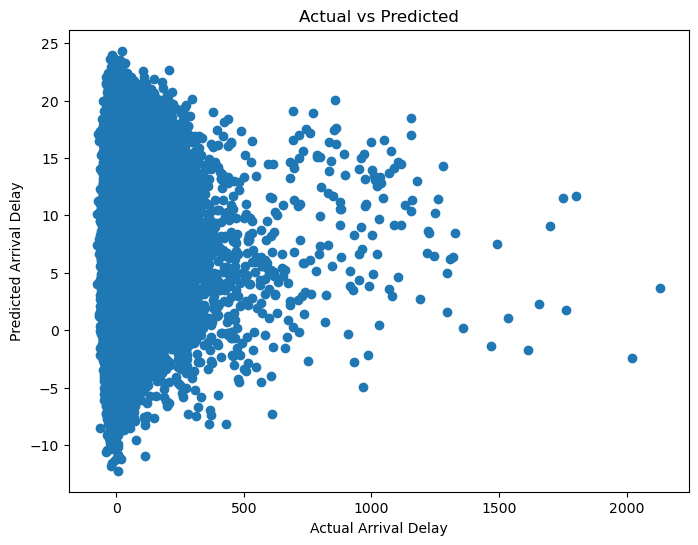

In [69]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_test_pred)
plt.xlabel("Actual Arrival Delay")
plt.ylabel("Predicted Arrival Delay")
plt.title("Actual vs Predicted")
plt.show()

In [52]:
residuals = y_test - y_test_pred

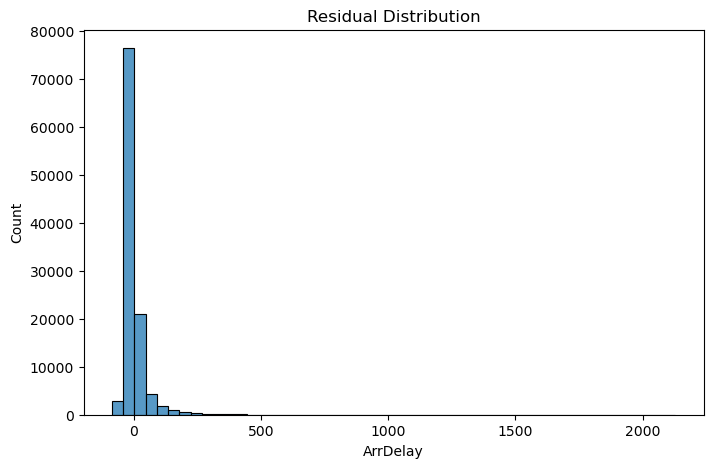

In [53]:
plt.figure(figsize=(8,5))

sns.histplot(residuals, bins=50)

plt.title("Residual Distribution")

plt.show()

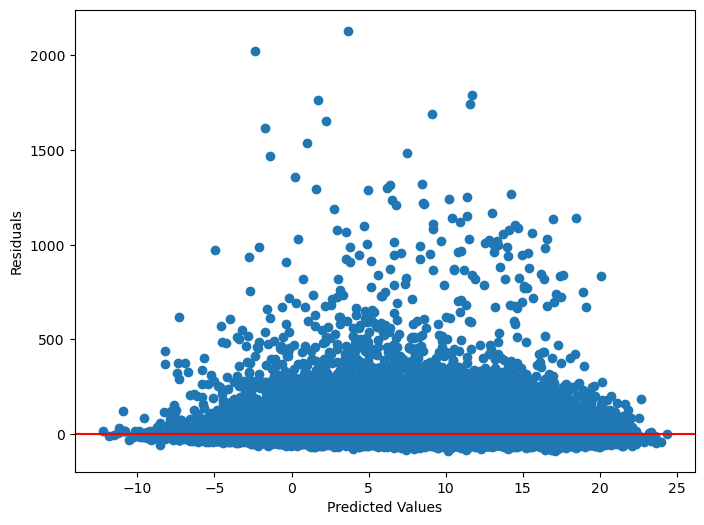

In [70]:
plt.figure(figsize=(8,6))

plt.scatter(y_test_pred, residuals)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.show()

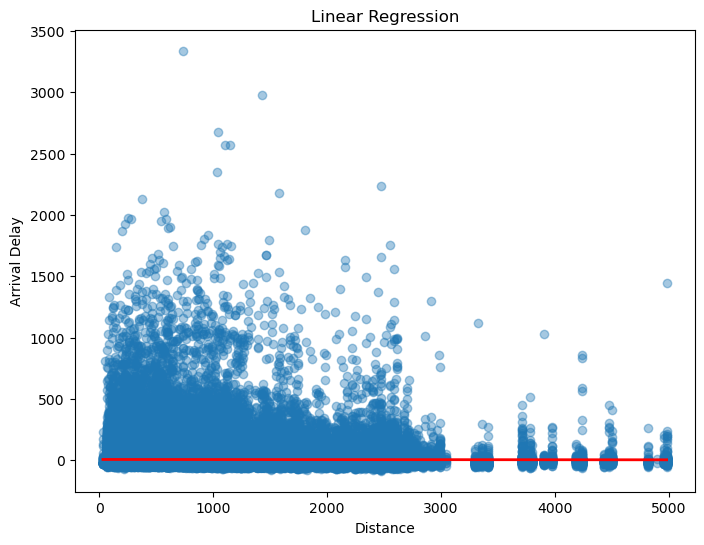

In [73]:
from sklearn.linear_model import LinearRegression

# Select one feature
X = df[['Distance']]
y = df['ArrDelay']

# Remove NaN values
mask = y.notna()
X = X[mask]
y = y[mask]

# Train model
model = LinearRegression()
model.fit(X, y)

# Predict
y_predict = model.predict(X)

# Sort for a smooth line
X_sorted = X.sort_values(by='Distance')
y_predict_sorted = model.predict(X_sorted)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(X['Distance'], y, alpha=0.4)
plt.plot(X_sorted['Distance'], y_predict_sorted, color='red', linewidth=2)

plt.xlabel("Distance")
plt.ylabel("Arrival Delay")
plt.title("Linear Regression")
plt.show()

In [75]:
# Train the model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

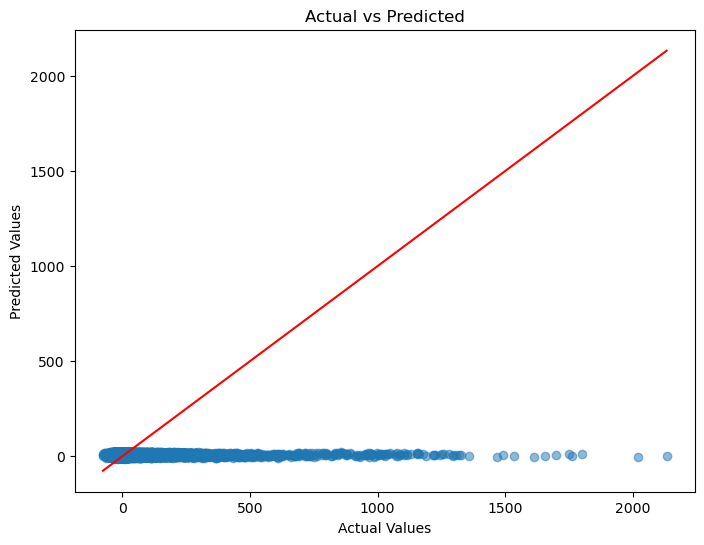

In [76]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

In [77]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X, y)

y_pred = model.predict(X)

In [78]:
y_pred = model.predict(X_test)

plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- CRSArrTime
- CRSDepTime
- CRSElapsedTime
- Cancelled
- DayOfWeek
- ...


In [79]:
print(model.feature_names_in_)

['Distance']


In [80]:
print(X_test.columns.tolist())

['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'OriginStateFips', 'OriginWac', 'DestStateFips', 'DestWac', 'CRSDepTime', 'CRSArrTime', 'Cancelled', 'Diverted', 'CRSElapsedTime', 'Flights', 'Distance', 'DistanceGroup']


In [100]:
# Define features and target
X = df.drop("ArrDelay", axis=1)
y = df["ArrDelay"]

# Remove rows where target is missing
mask = y.notna()
X = X[mask]
y = y[mask]

# Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

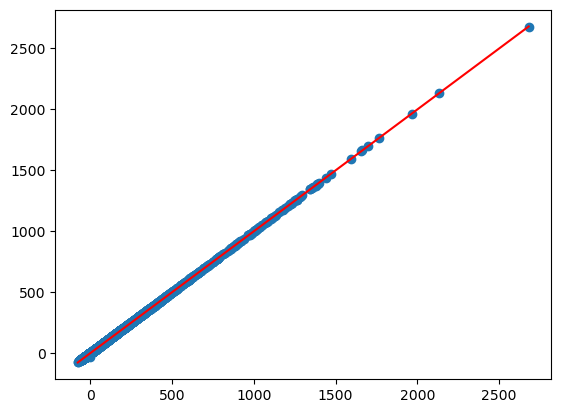

In [101]:
y_pred = model.predict(X_test)

plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

In [88]:
X = X.fillna(X.mean())

In [89]:
X = X.fillna("Unknown")

In [91]:
X = X.drop(columns=[
    'Div1Airport',
    'Div2Airport',
    'Div3Airport',
    'Div4Airport',
    'Div5Airport',
    'CancellationCode'
], errors='ignore')

In [92]:
X.isnull().sum().sum()

np.int64(0)

In [94]:
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])


CarrierDelay            327724
WeatherDelay            327724
NASDelay                327724
SecurityDelay           327724
LateAircraftDelay       327724
FirstDepTime            410822
TotalAddGTime           410822
LongestAddGTime         410822
DivReachedDest          413777
DivActualElapsedTime    413777
DivArrDelay             413777
DivDistance             413777
Div1AirportID           413777
Div1AirportSeqID        413777
Div1WheelsOn            413777
Div1TotalGTime          413777
Div1LongestGTime        413777
Div1WheelsOff           413777
Div2AirportID           413777
Div2AirportSeqID        413777
Div2WheelsOn            413777
Div2TotalGTime          413777
Div2LongestGTime        413777
Div2WheelsOff           413777
Div3Airport             413777
Div3AirportID           413776
Div3AirportSeqID        413776
Div3WheelsOn            413777
Div3TotalGTime          413777
Div3LongestGTime        413777
Div3WheelsOff           413777
Div3TailNum             413777
Div4Airp

In [95]:
# Drop columns with more than 50% missing values
threshold = len(df) * 0.5

df = df.dropna(axis=1, thresh=threshold)

In [96]:
missing_percent = (df.isnull().sum() / len(df)) * 100

print(missing_percent[missing_percent > 50])

Series([], dtype: float64)


In [97]:
cols_to_drop = [
'CarrierDelay','WeatherDelay','NASDelay','SecurityDelay','LateAircraftDelay',
'FirstDepTime','TotalAddGTime','LongestAddGTime',
'DivReachedDest','DivActualElapsedTime','DivArrDelay','DivDistance',
'Div1AirportID','Div1AirportSeqID','Div1WheelsOn','Div1TotalGTime',
'Div1LongestGTime','Div1WheelsOff',
'Div2AirportID','Div2AirportSeqID','Div2WheelsOn','Div2TotalGTime',
'Div2LongestGTime','Div2WheelsOff',
'Div3Airport','Div3AirportID','Div3AirportSeqID','Div3WheelsOn',
'Div3TotalGTime','Div3LongestGTime','Div3WheelsOff','Div3TailNum',
'Div4Airport','Div4AirportID','Div4AirportSeqID','Div4WheelsOn',
'Div4TotalGTime','Div4LongestGTime','Div4WheelsOff','Div4TailNum',
'Div5Airport','Div5AirportID','Div5AirportSeqID','Div5WheelsOn',
'Div5TotalGTime','Div5LongestGTime','Div5WheelsOff','Div5TailNum',
'Unnamed: 109'
]

df = df.drop(columns=cols_to_drop, errors='ignore')

In [98]:
print(df.isnull().sum()[df.isnull().sum() > 0])

Series([], dtype: int64)
